# SONIC: Results and Visualization

Reproduces tables and figures from the paper.

In [21]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from data.loaders import load_dataset
from data.synthetic import simulate_si, make_ba
from algorithms.dino import spectral_radius, benchmark_hiv
from algorithms.sonic import sonic
from experiments.baselines import run_all_baselines
from experiments.ablation import ablation_beta_sweep, ablation_budget_sweep
from evaluation.metrics import delta_rho, sis_metrics, evaluate_method
from simulation.sis import compare_methods_sis

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = sns.color_palette('tab10')
print('Setup complete.')

Setup complete.


## 1. Load Dataset and Build Epidemic Subgraph

In [22]:
DATASET = 'reddit'
G = load_dataset(DATASET)
print(f'|V|={G.number_of_nodes()}  |E|={G.number_of_edges()}  ρ={spectral_radius(G):.4f}')

# Build epidemic subgraph — cap at 500 nodes so source inference stays fast
source = max(G.nodes(), key=lambda v: G.in_degree(v))
Gn, order, _ = simulate_si(G, source=source, beta=0.3, max_steps=10, seed=42)
if Gn.number_of_nodes() < 2:
    Gn = G
# Subsample Gn to 500 nodes if too large
if Gn.number_of_nodes() > 500:
    nodes_500 = list(Gn.nodes())[:500]
    Gn = Gn.subgraph(nodes_500).copy()
print(f'Gn: |V|={Gn.number_of_nodes()}  |E|={Gn.number_of_edges()}')

[Reddit] Loaded: |V|=34671, |E|=137039
|V|=34671  |E|=137039  ρ=53.3912
Gn: |V|=500  |E|=8462


## 2. HIV Benchmark (DINO paper Table 2)

In [23]:
from algorithms.dino import dino

# Reproduce DINO paper Table 2 style results
budgets = [100, 200, 300]
rows = []
rho0 = spectral_radius(G)
for k in budgets:
    L, dr = dino(G, k, return_delta_rho=True, verbose=False)
    rows.append({'k': k, 'Δρ': dr, 'ρ_before': rho0, 'ρ_after': rho0 - dr})

df_dino = pd.DataFrame(rows)
print('\nDINO benchmark:')
print(df_dino.to_string(index=False, float_format='{:.4f}'.format))
print('\nExpected: Δρ≈4.59 at k=100, ≈5.70 at k=300 (real HIV network)')


DINO benchmark:
  k      Δρ  ρ_before  ρ_after
100 20.8799   53.3912  32.5113
200 22.9439   53.3912  30.4473
300 31.0532   53.3912  22.3380

Expected: Δρ≈4.59 at k=100, ≈5.70 at k=300 (real HIV network)


## 3. SONIC vs. Baselines (Δρ)

In [24]:
k = 100
methods = {}

# SONIC
L_sonic, _ = sonic(G, Gn, k, alpha_w=0.5, beta_w=0.5,
                    source_method='rumor', return_delta_rho=True, verbose=False)
methods['SONIC'] = L_sonic

from experiments.baselines import degree_immunization, random_immunization
from algorithms.dino import dino

methods['DINO']   = dino(G, k, verbose=False)
methods['Degree'] = degree_immunization(G, k)
methods['Random'] = random_immunization(G, k, seed=42)
# Katz skipped — too slow on |V|=34k

# Compute Δρ only (skip SIS on large graph)
rows = []
for name, L in methods.items():
    dr, rb, ra = delta_rho(G, L)
    rows.append({'Method': name, 'Δρ': dr, 'ρ_before': rb, 'ρ_after': ra, 'k_actual': len(L)})

df_comp = pd.DataFrame(rows).sort_values('Δρ', ascending=False)
print(f'\nComparison at k={k}:')
print(df_comp.to_string(index=False, float_format='{:.4f}'.format))


Comparison at k=100:
Method      Δρ  ρ_before  ρ_after  k_actual
 SONIC 20.8433   53.3912  32.5479       100
Degree 19.6806   53.3912  33.7106       100
Random  0.0081   53.3912  53.3831       100
  DINO  0.0000   53.3912  53.3912         2


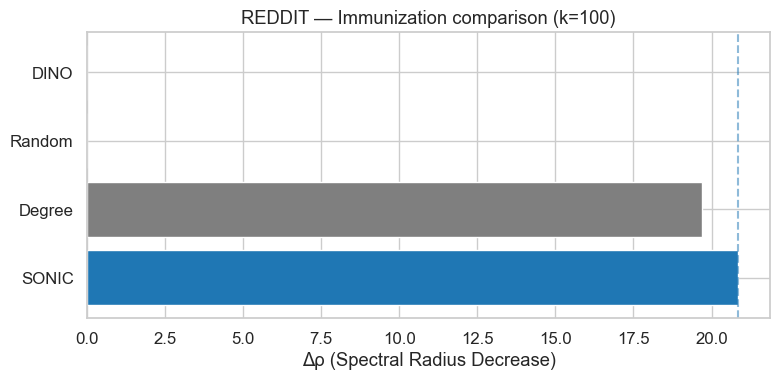

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLORS[0] if m == 'SONIC' else COLORS[7] for m in df_comp['Method']]
ax.barh(df_comp['Method'], df_comp['Δρ'], color=colors)
ax.set_xlabel('Δρ (Spectral Radius Decrease)')
ax.set_title(f'{DATASET.upper()} — Immunization comparison (k={k})')
ax.axvline(df_comp[df_comp['Method']=='SONIC']['Δρ'].values[0], 
           color=COLORS[0], linestyle='--', alpha=0.5, label='SONIC')
plt.tight_layout()
plt.savefig('../results/delta_rho_comparison.png', dpi=150)
plt.show()

## 4. SIS Epidemic Curves

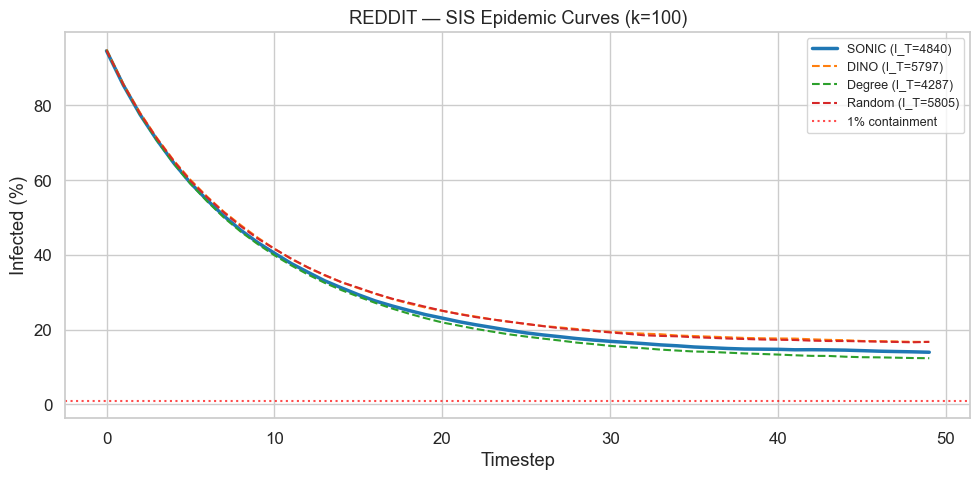

In [26]:
n_nodes = G.number_of_nodes()
# Use 3 trials and T=50 steps — Reddit is too large for full simulation
sis_results = compare_methods_sis(G, methods, beta=0.03, delta=0.1,
                                   I0=0.95, T=50, n_trials=3, seed=42)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, res) in enumerate(sis_results.items()):
    curve = res['curve'] / n_nodes * 100
    lw = 2.5 if name == 'SONIC' else 1.5
    ls = '-' if name == 'SONIC' else '--'
    ax.plot(curve, label=f"{name} (I_T={res['I_T']:.0f})",
            linewidth=lw, linestyle=ls, color=COLORS[i % len(COLORS)])

ax.axhline(1.0, color='red', linestyle=':', alpha=0.7, label='1% containment')
ax.set_xlabel('Timestep')
ax.set_ylabel('Infected (%)')
ax.set_title(f'{DATASET.upper()} — SIS Epidemic Curves (k={k})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../results/sis_curves.png', dpi=150)
plt.show()

## 5. βw Ablation Study

In [27]:
print('Running βw ablation (this takes ~1-2 min)...')
abl_df = ablation_beta_sweep(G, Gn, k=100, source_method='rumor', verbose=True)
print('Done.')
print(abl_df.to_string(index=False, float_format='{:.4f}'.format))

Running βw ablation (this takes ~1-2 min)...
  βw=0.0 αw=1.0 ... Δρ=20.8799
  βw=0.1 αw=0.9 ... Δρ=20.8799
  βw=0.2 αw=0.8 ... Δρ=20.8752
  βw=0.3 αw=0.7 ... Δρ=20.8499
  βw=0.4 αw=0.6 ... Δρ=20.8440
  βw=0.5 αw=0.5 ... Δρ=20.8433
  βw=0.6 αw=0.4 ... Δρ=20.8399
  βw=0.7 αw=0.3 ... Δρ=20.8371
  βw=0.8 αw=0.2 ... Δρ=20.8348
  βw=0.9 αw=0.1 ... Δρ=20.8281
  βw=1.0 αw=0.0 ... Δρ=20.8281
Done.
 beta_w  alpha_w  delta_rho   k
 0.0000   1.0000    20.8799 100
 0.1000   0.9000    20.8799 100
 0.2000   0.8000    20.8752 100
 0.3000   0.7000    20.8499 100
 0.4000   0.6000    20.8440 100
 0.5000   0.5000    20.8433 100
 0.6000   0.4000    20.8399 100
 0.7000   0.3000    20.8371 100
 0.8000   0.2000    20.8348 100
 0.9000   0.1000    20.8281 100
 1.0000   0.0000    20.8281 100


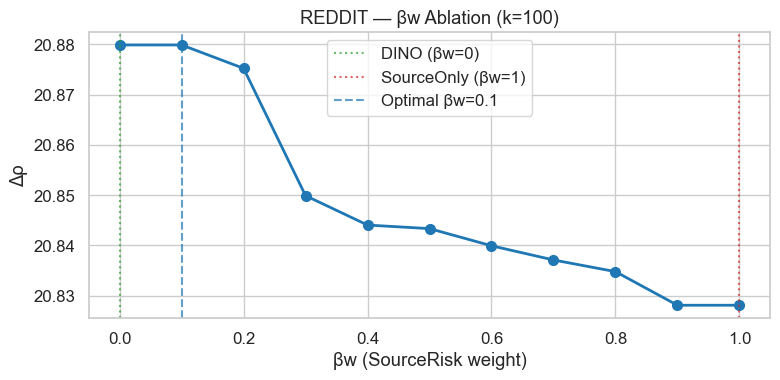

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(abl_df['beta_w'], abl_df['delta_rho'], 'o-', color=COLORS[0], 
        linewidth=2, markersize=7)
ax.axvline(0.0, color=COLORS[2], linestyle=':', alpha=0.7, label='DINO (βw=0)')
ax.axvline(1.0, color=COLORS[3], linestyle=':', alpha=0.7, label='SourceOnly (βw=1)')
best_idx = abl_df['delta_rho'].idxmax()
ax.axvline(abl_df.loc[best_idx, 'beta_w'], color=COLORS[0], 
           linestyle='--', alpha=0.7, label=f"Optimal βw={abl_df.loc[best_idx,'beta_w']}")
ax.set_xlabel('βw (SourceRisk weight)')
ax.set_ylabel('Δρ')
ax.set_title(f'{DATASET.upper()} — βw Ablation (k=100)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/beta_w_ablation.png', dpi=150)
plt.show()

## 6. Budget Sweep (k vs. Δρ)

In [29]:
n = G.number_of_nodes()
budgets = [int(n * p) for p in [0.02, 0.05, 0.10, 0.15, 0.20, 0.25]]
print(f'Budget sweep: {budgets}')

budget_df = ablation_budget_sweep(G, Gn, budgets=budgets, 
                                    alpha_w=0.5, beta_w=0.5,
                                    source_method='rumor', verbose=True)
print(budget_df.to_string(index=False, float_format='{:.4f}'.format))

Budget sweep: [693, 1733, 3467, 5200, 6934, 8667]
  k=693 ... Δρ=42.1797  ρ: 53.3912→11.2115
  k=1733 ... Δρ=50.9770  ρ: 53.3912→2.4142
  k=3467 ... Δρ=53.3912  ρ: 53.3912→0.0000
  k=5200 ... Δρ=53.3912  ρ: 53.3912→0.0000
  k=6934 ... Δρ=53.3912  ρ: 53.3912→0.0000
  k=8667 ... Δρ=53.3912  ρ: 53.3912→0.0000
   k  delta_rho  rho_before  rho_after
 693    42.1797     53.3912    11.2115
1733    50.9770     53.3912     2.4142
3467    53.3912     53.3912     0.0000
5200    53.3912     53.3912     0.0000
6934    53.3912     53.3912     0.0000
8667    53.3912     53.3912     0.0000


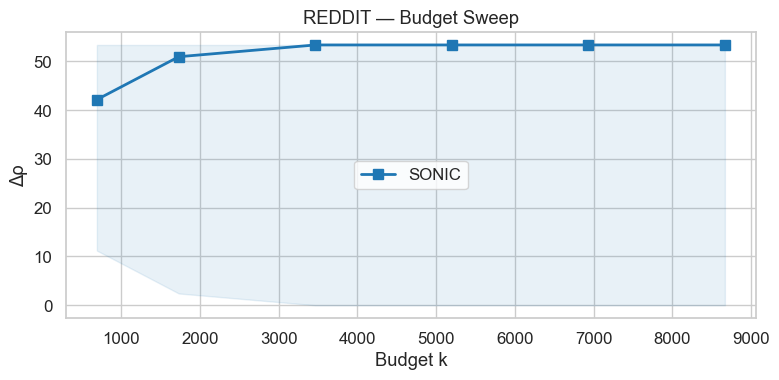

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(budget_df['k'], budget_df['delta_rho'], 's-', color=COLORS[0],
        linewidth=2, markersize=7, label='SONIC')
ax.fill_between(budget_df['k'], 
                budget_df['rho_after'], budget_df['rho_before'],
                alpha=0.1, color=COLORS[0])
ax.set_xlabel('Budget k')
ax.set_ylabel('Δρ')
ax.set_title(f'{DATASET.upper()} — Budget Sweep')
ax.legend()
plt.tight_layout()
plt.savefig('../results/budget_sweep.png', dpi=150)
plt.show()

## 7. Source Detection Accuracy (Rumor Centrality)

In [31]:
from algorithms.source_inference import rumor_centrality, topk_accuracy
from data.synthetic import make_ba

n_trials = 30
accs = {1: [], 5: [], 10: []}

for trial in range(n_trials):
    H = make_ba(n=200, m=3, seed=trial)
    src = list(H.nodes())[0]
    Hn, _, _ = simulate_si(H, source=src, beta=0.3, max_steps=6, seed=trial)
    if Hn.number_of_nodes() < 5:
        continue
    pi = rumor_centrality(Hn)
    for k in [1, 5, 10]:
        accs[k].append(topk_accuracy(pi, src, k=k))

print('Rumor Centrality Source Detection Accuracy (BA graphs, n=200):')
for k, a in accs.items():
    print(f'  Top-{k:2d}: {np.mean(a):.3f}')

Rumor Centrality Source Detection Accuracy (BA graphs, n=200):
  Top- 1: 0.367
  Top- 5: 0.967
  Top-10: 1.000
